前面在介绍指针类型时，已经知道指针变量圈定的内存大小跟编译器有关或者说跟CPU的地址总线有关。在32位的系统中，指针类型占用4byte，在64位的系统中，指针类型占用8byte。指针变量的值有特殊意义，代表了一个地址编号，本章讲重点讲指针访问内存的规则和技巧.另外，希望大家对这两个概念:指针和指针变量，有清晰的区分。我们一般说指针，代表就是这个指针变量的值，即内存地址;指针变量就是一个变量，用于存放内存地址。
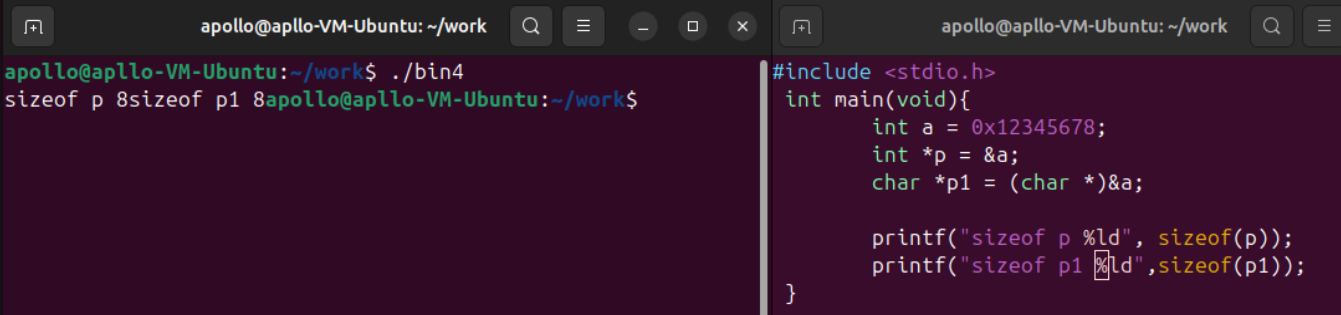

# 1.指针变量的初始化
大家要养成思维习惯:每当看到一个指针变量，要对其值的合法性保持敬畏。
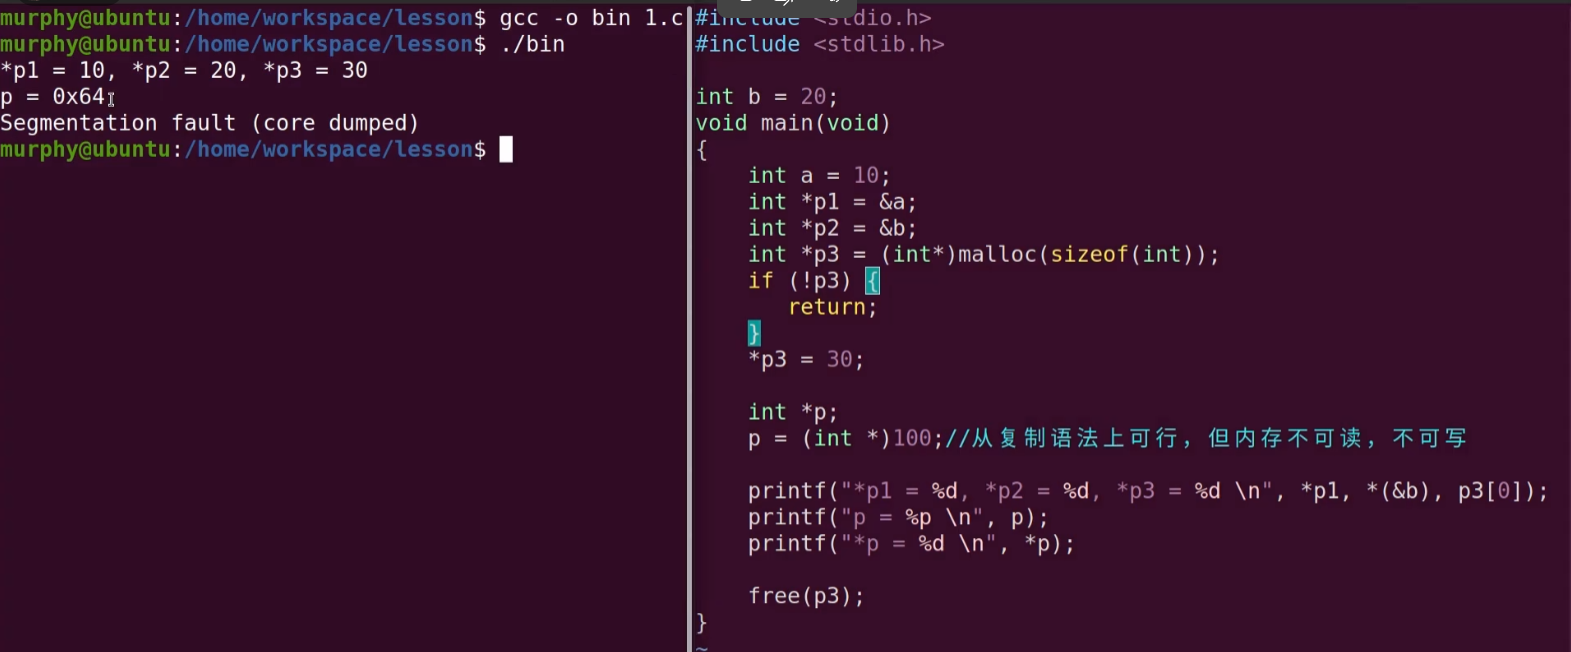

# 2.空指针和野指针
- 空指针很好理解，就是值为0(NULL)的指针变量，如果访问了0地址就会出现非法访问的错误。

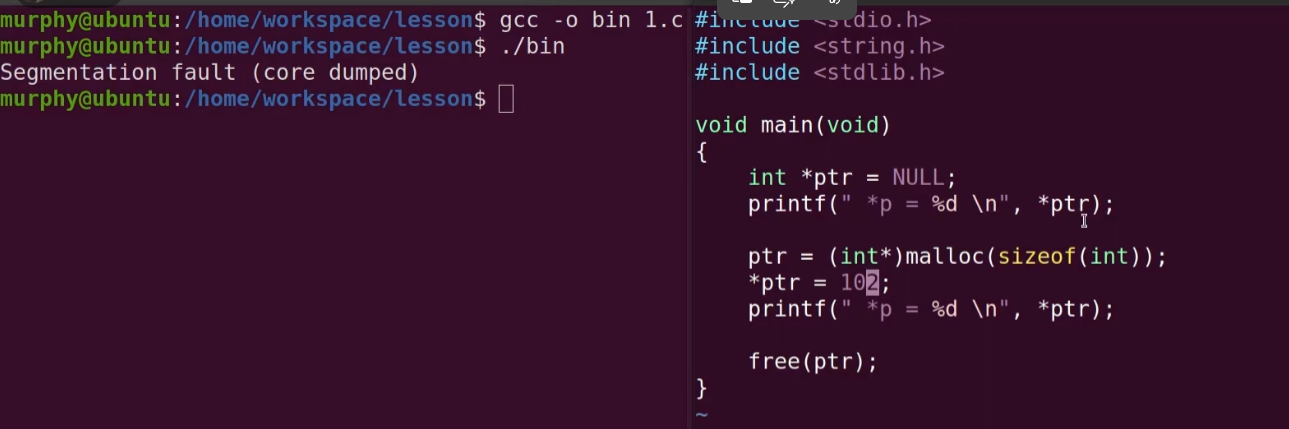
- 野指针是指值为非法地址的指针变量，野指针在实际工程中有很大的危害，会造成代码的稳定问题(不可预知的bug)。野指针也可以是合法的地址，但是如果free之后没有置空（NULL），就会被其他指针指向。所以要在free后，把指针变量置空(NULL)的习惯。
  
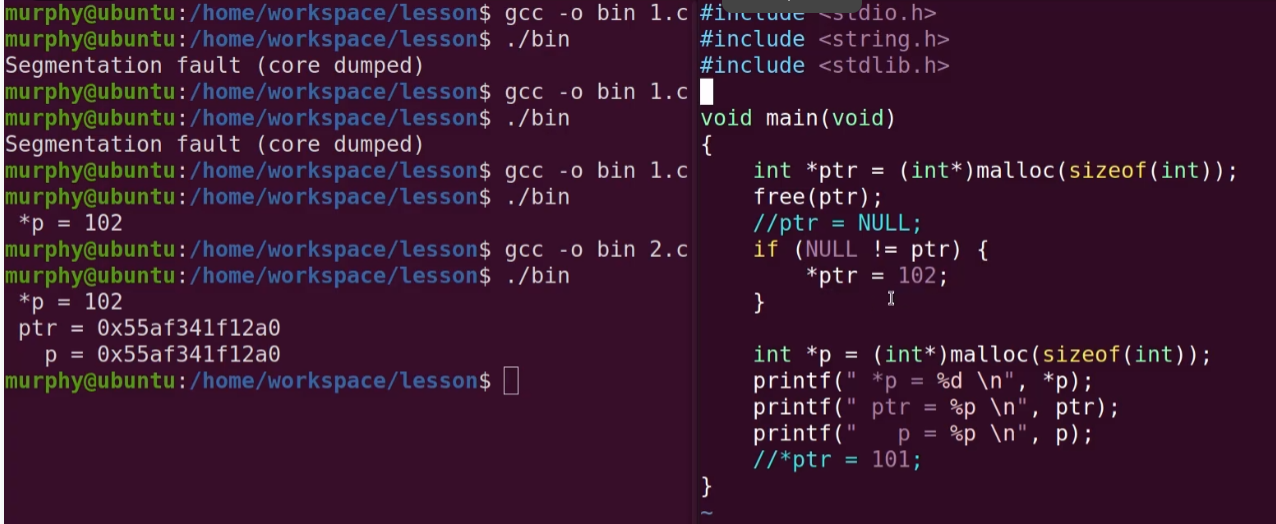

# 2. 指针访问内存
要访问指针指向的地址，那就必然需要回答两个问题:1、内存的可读可写性是什么?2、内存的访问规则是什么?

- 指针访问内存的规则
我们前面学过几种指针访问内存的方式:p、p[x]、p->X。那每次访问的大小是多少呢?我们知道指针变量的定义的形式是: 数据类型* p;所以每次访问的大小由前面修饰的数据类型决定。

## 2.1 标准数据类型的指针访问内存
这里面还会设计到一个大小端的问题，后续要深度研究。

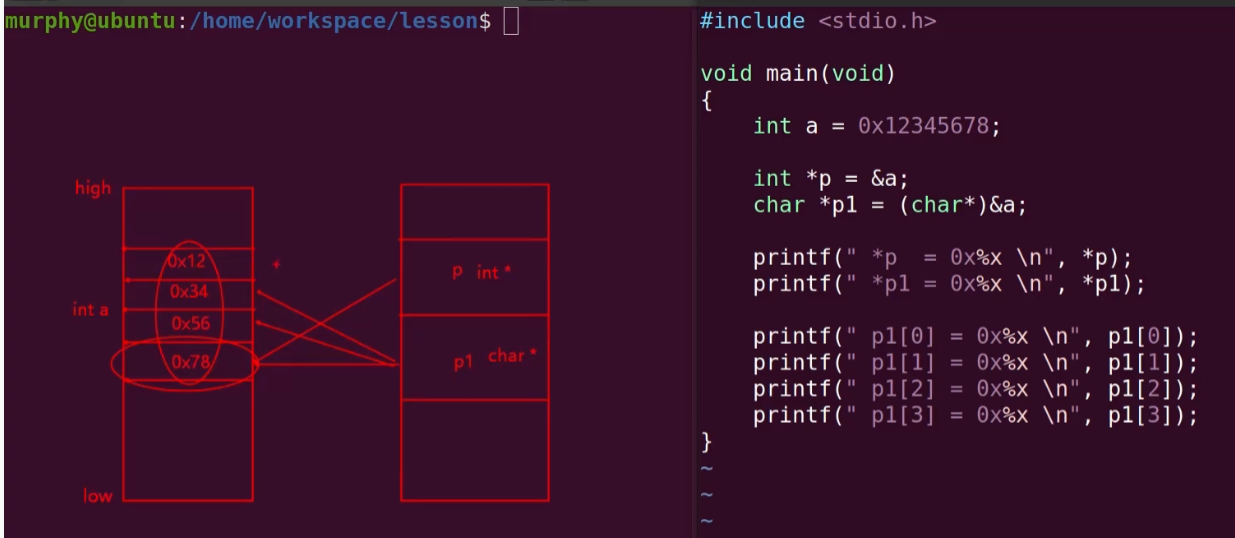

## 2.2 连续空间的指针访问内存
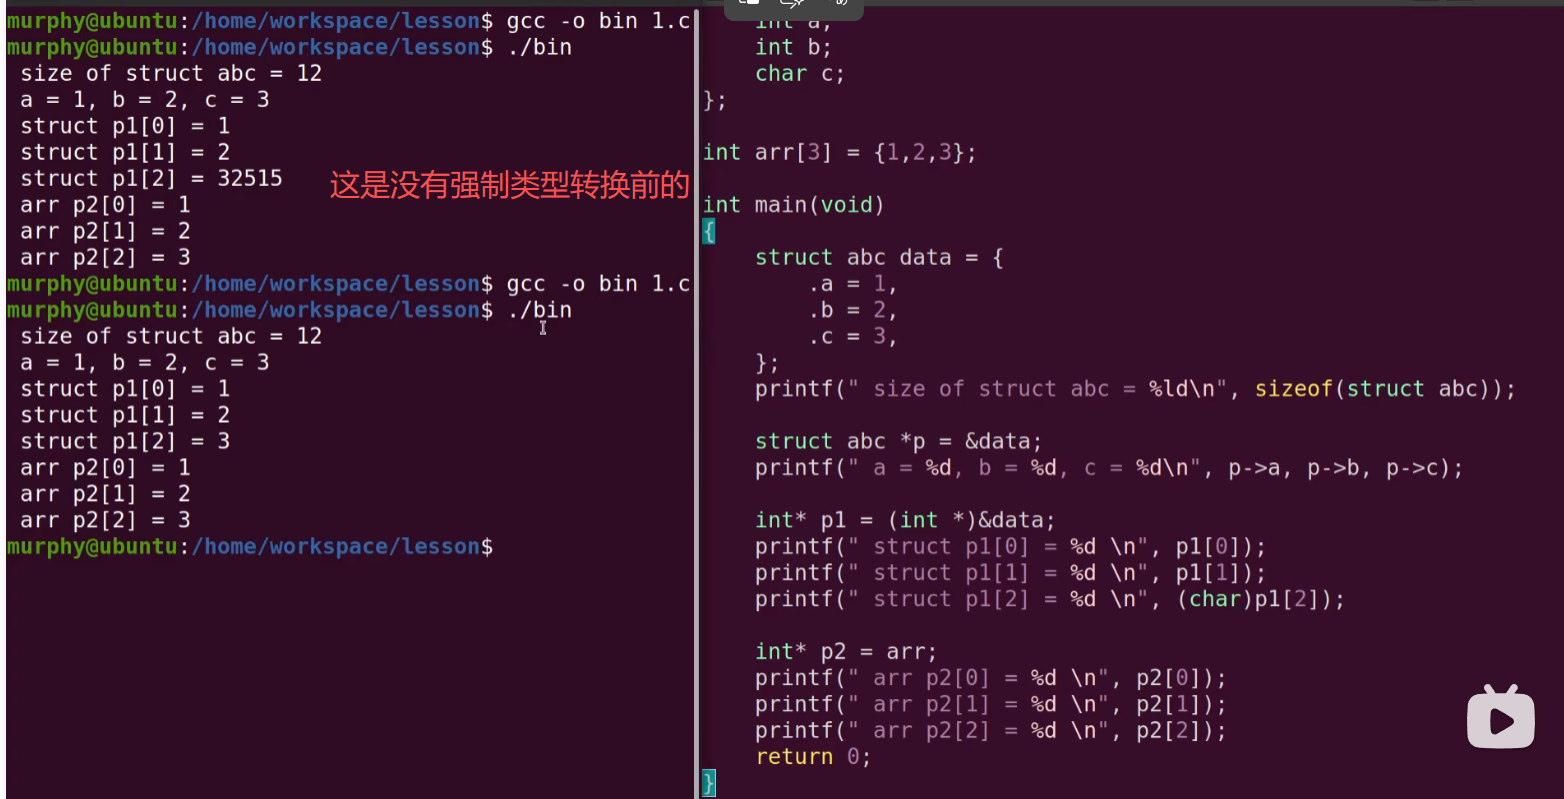

## 2.3 函数类型的指针访问内存
- 右左原则来判断是函数指针还是指针函数

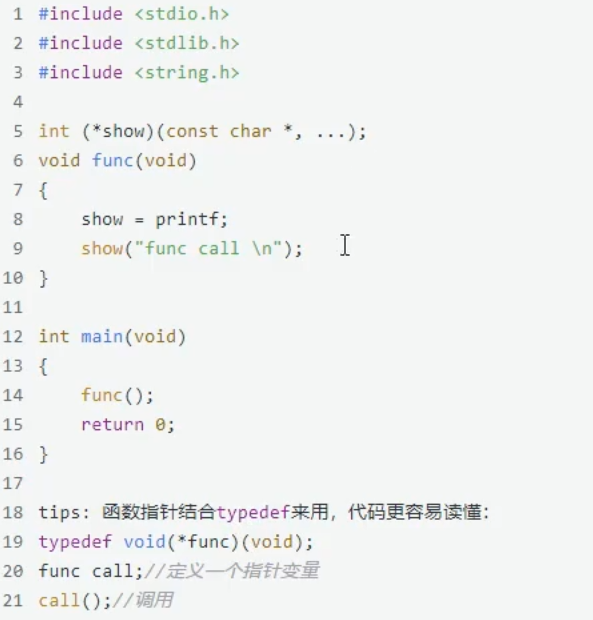

## 2.4 linux内核第一宏container_of
container_of是linux内核中一个非常重要的宏，主要用于通过结构体成员的地址来获取结构体的地址。这个宏的定义如下：
```c
#define offsetof(type, member) ((size_t) &((type *)0)->member)
#define container_of(ptr, type, member) ({                      \
    const typeof( ((type *)0)->member ) *__mptr = (ptr);        \
    (type *)( (char *)__mptr - offsetof(type, member) );        \
})
```
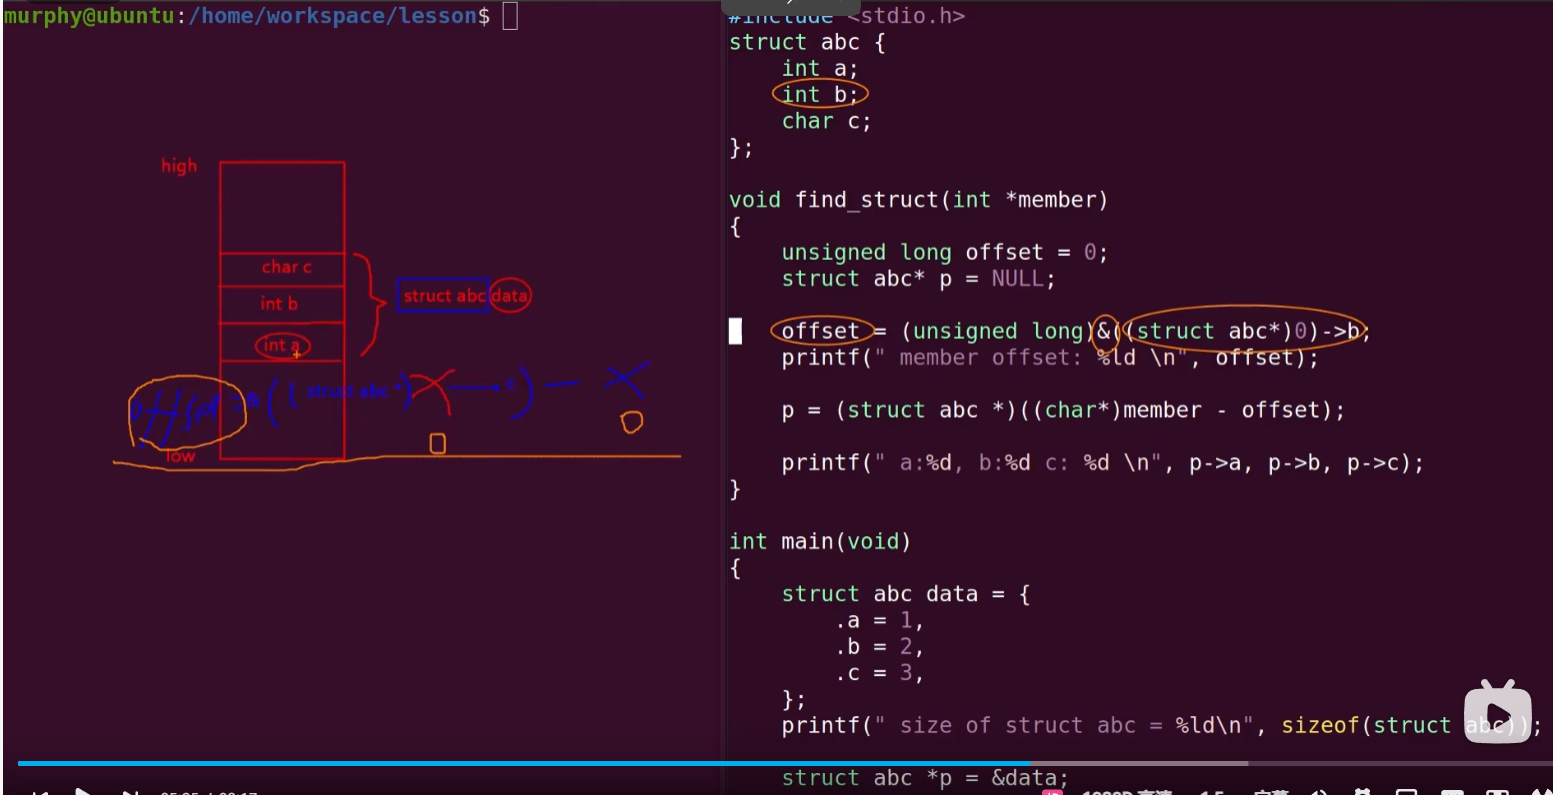

# 3. 指针运算

## 3.1 指针的算数运算
指针+、-、++、--运算指针变量本质也是一个变量，所以进行算数运算语法上是可以的。但是实际的工程应用中，指针变量的乘除法没有意义，更多的是加减法。总的来说，+运算符用于指针的算术运算，允许将指针移动到任意偏移位置，而++运算符是+运算符的特例，它递增指针指向的位置移动一个对象的大小。
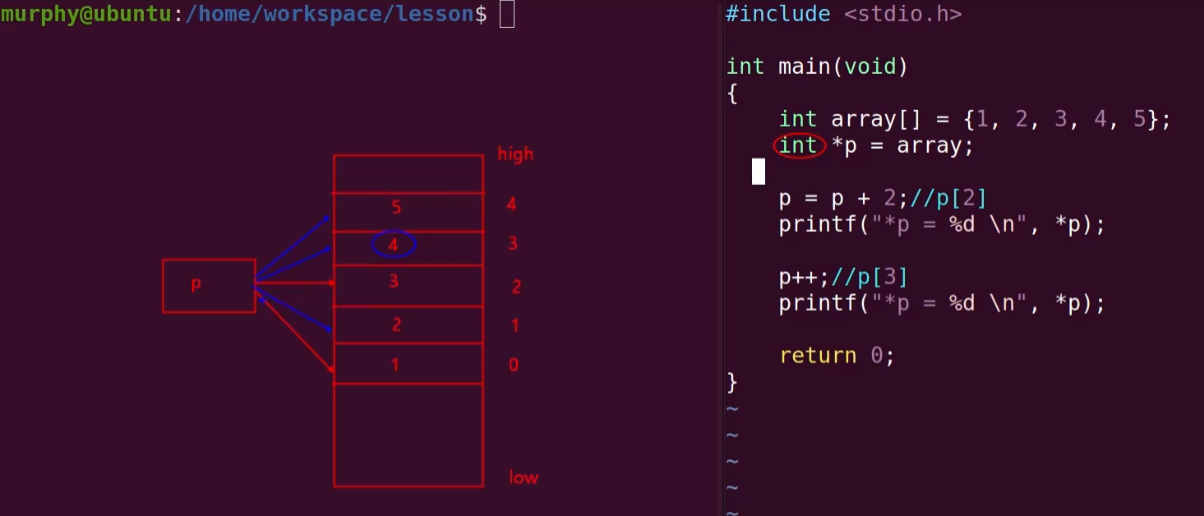

## 3.2 指针的逻辑运算
逻辑运算中，判断两个指针是否相等比较常用，其他的不常用。另外，只有两个相同类型的指针比较才有意义，一般编译也会包警告，如果类型不同。

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main(void)
{
    // 分配一个int类型的堆内存，p是int*类型指针
    int *p = (int*)malloc(sizeof(int));
    if (p == NULL) {
        return -1;
    }
    char *p1 = NULL;
    // 用于提示两个指针类型不同的警告
    if (p1 == p) { // warning: comparison of distinct pointer types lacks a cast
        // do something
    }

    free(p);
    return 0;
}

linux下的MAX实现

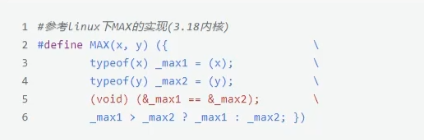

# 4. 多级指针
多级指针本质上也是一个指针，也需要一个指针变量来存放。这个指针变量的内存大小跟一级指针一样，跟系统有关。

## 4.1 二级指针

```c
int **p
1. *p第一个 "*"决定变量p是一个指针变量
2. **p第二个 "*"决定指针p访问内存规则是以指针类型进行访问，所以*p的值还是一个指针(地址)
3. int 决定指针(*p)访问内存规则是以int类型进行访问,所以*(*p)是int类型
```

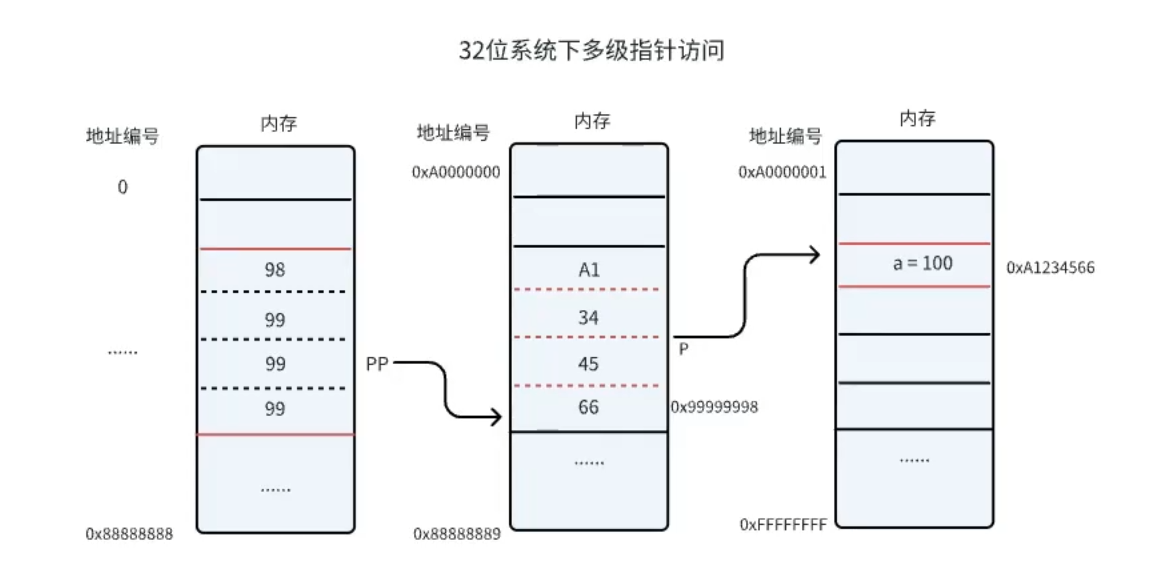
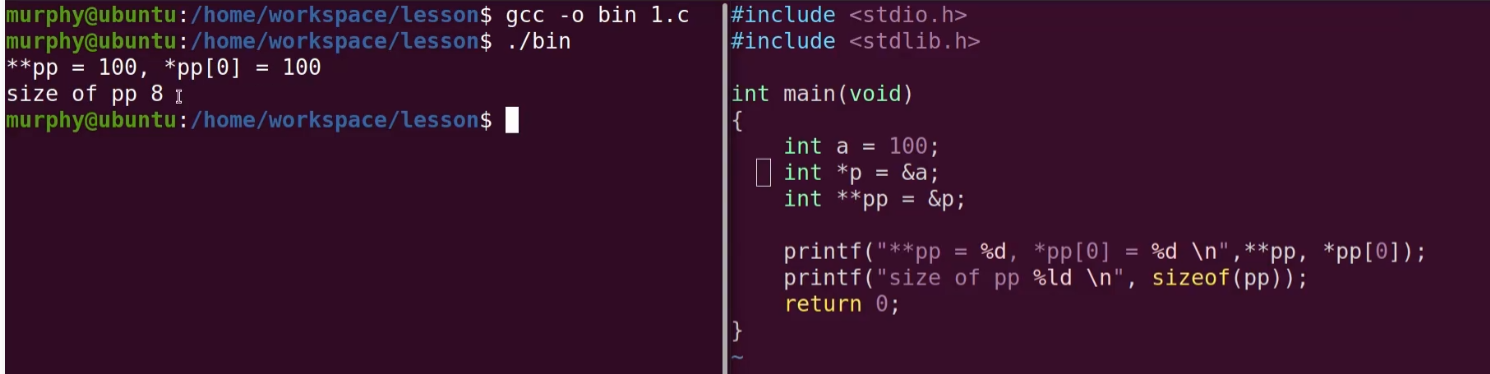

## 4.2 用于指针变量地址传递
- C 语言所有参数都是值传递，函数拿到的永远是原变量的副本
- 传一级指针：只能修改指针指向的内容，不能修改指针本身
- 传二级指针：可以修改一级指针本身的值
- 万能法则：想修改什么类型的变量，就传什么类型的指针

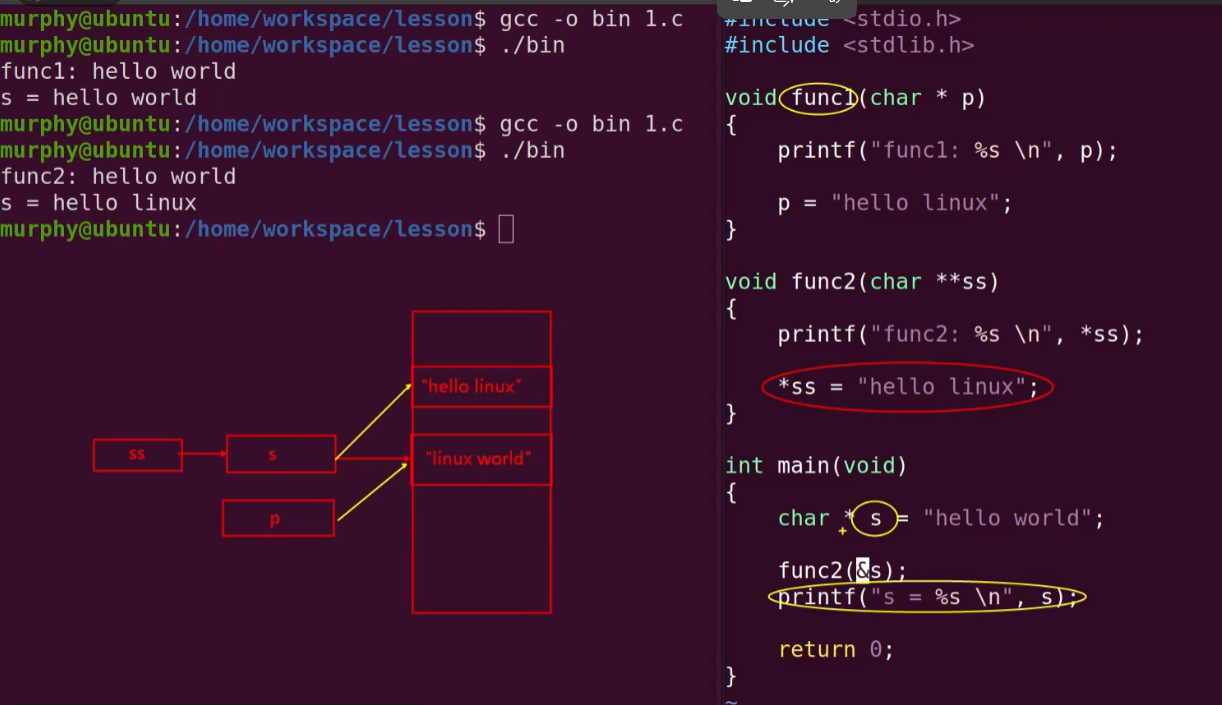

```c
void func1(char *p) {
    printf("func1: %s \n", p);
    * p = "hello linux"; 
}
```
绝对不行！这是一个比原来更严重的错误，会直接导致程序崩溃（Segmentation fault），而且是 C 语言中最容易踩的字符串陷阱之一。
- 一、先看这行代码的本质错误
*p = "hello linux";

这行代码有两个致命错误，一个是类型不匹配，另一个是非法写入只读内存。
- 错误 1：严重的类型不匹配
*p 的类型是 char（一个字节的字符）
"hello linux" 的类型是 const char[12]（字符串常量），在赋值时会退化为 const char* 类型（一个 8 字节的指针地址）
所以这行代码实际上做的是：把字符串常量 "hello linux" 在内存中的地址值（比如 0x400610），强制截断成一个字节，然后写入到 p 指向的内存地址。这完全不是想要的 "给字符串赋值" 的效果。
- 错误 2：写入只读内存（直接导致崩溃）
p 指向的是哪里？它指向的是 main 函数中的 "hello world"，而所有的字符串字面量都存储在内存的只读数据段（.rodata），这个区域的内存是不可写的。

所以当你执行 *p = ... 时，相当于试图修改一个只读的内存地址，操作系统会立即杀死你的进程，抛出 Segmentation fault（段错误）。

```c
void func1(int *p) {
    printf("func1: 原来的值 = %d \n", *p);
    *p = 100; // 这行完全正确，没有任何问题
}
```
这样就是一个标准的指针传递。

## 4.3 多级指针用于物理无序的映射到逻辑有序的数据结构设计
多级指针的一个重要应用场景是：物理无序的映射到逻辑有序的数据结构设计。比如我们有一个物理上无序的链表结构，但是我们想要通过多级指针来实现一个逻辑上有序的数据访问方式。这种设计可以大大简化代码的复杂度，提高数据访问的效率。
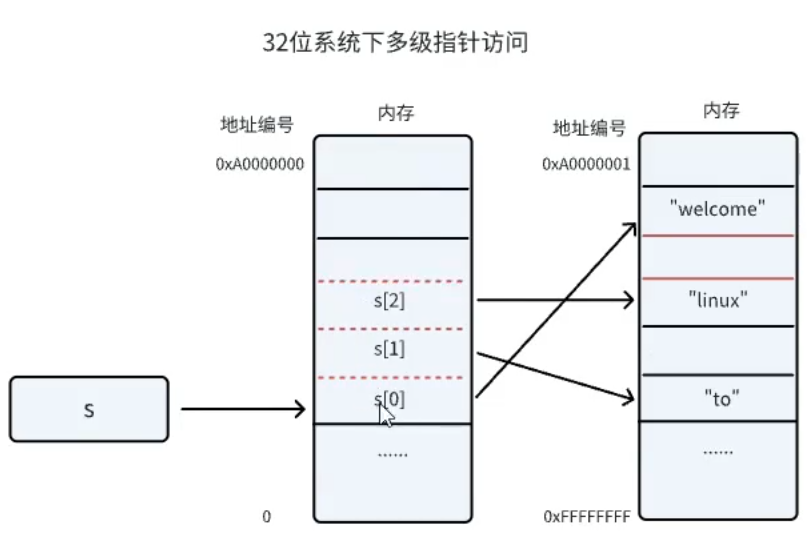
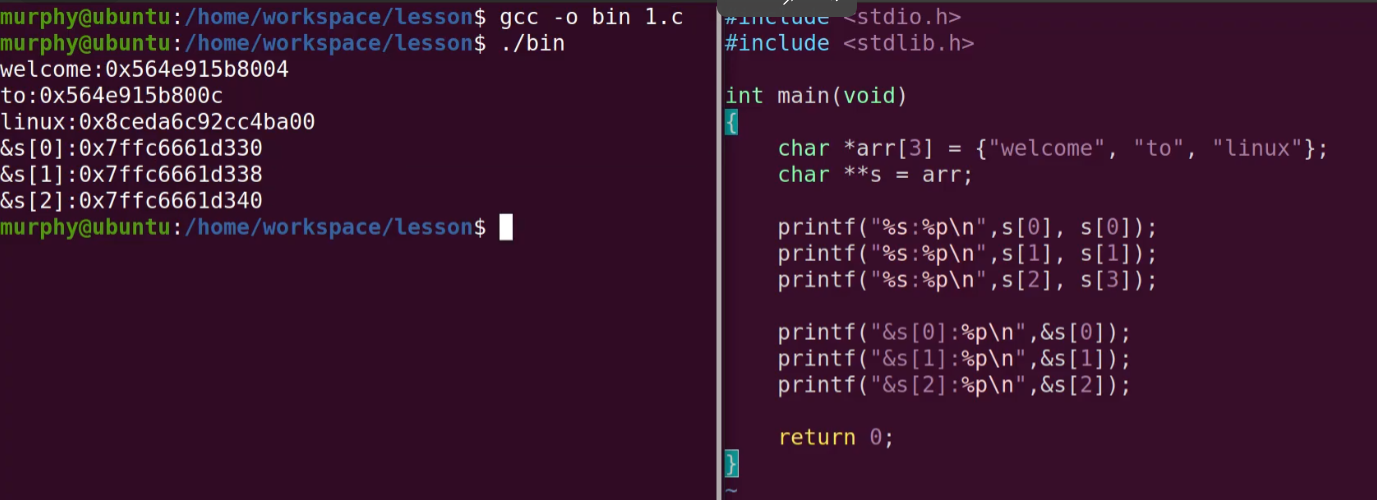

# 5. 复杂类型定义
右左原则:以变量为中心，先向右解析，再向左解析。
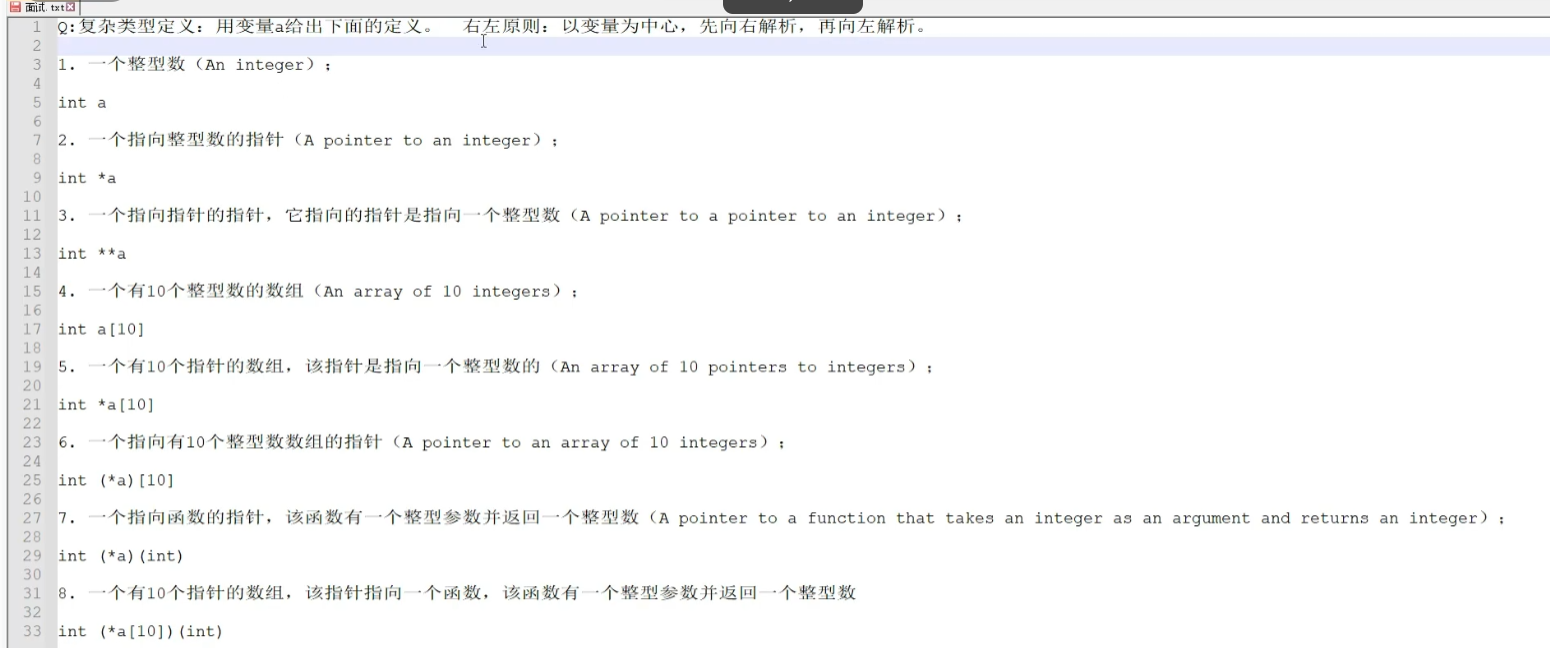

# 6. 复杂类型定义练习
1. 一个整型数（An integer）；
   
2. 一个指向整型数的指针（A pointer to an integer）；
   
3. 一个指向指针的指针，它指向的指针是指向一个整型数（A pointer to a pointer to an integer）；
   
4. 一个有 10 个整型数的数组（An array of 10 integers）；
   
5. 一个有 10 个指针的数组，该指针是指向一个整型数的（An array of 10 pointers to integers）；
   
6. 一个指向有 10 个整型数数组的指针（A pointer to an array of 10 integers）；
   
7. 一个指向函数的指针，该函数有一个整型参数并返回一个整型数（A pointer to a function that takes an integer as an argument and returns an integer）；
   
8. 一个有 10 个指针的数组，该指针指向一个函数，该函数有一个整型参数并返回一个整型数。

翻译

int a

int * a

int ** a

int a[10]

int * a[10]

int  (*a)[10]

int (*a)(int b)

int (* a[10])(int a)